In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [2]:
class QuadraticState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str

In [13]:
def show_equation(state: QuadraticState):
    a = state['a']
    b = state['b']
    c = state['c']
    equation = f"{a}x^2 + {b}x + {c} = 0"
    return {"equation": equation}

def calculate_discriminant(state: QuadraticState):
    a = state['a']
    b = state['b']
    c = state['c']
    discriminant = b**2 - 4*a*c
    return {"discriminant": discriminant}

def real_roots(state: QuadraticState):
    a = state['a']
    b = state['b']
    discriminant = state['discriminant']
    root1 = (-b + discriminant**0.5) / (2*a)
    root2 = (-b - discriminant**0.5) / (2*a)
    return {"result": f"The roots are real and distinct: {root1} and {root2}"}

def complex_roots(state: QuadraticState):
    a = state['a']
    b = state['b']
    discriminant = state['discriminant']
    real_part = -b / (2*a)
    imaginary_part = (abs(discriminant)**0.5) / (2*a)
    return {"result": f"The roots are complex: {real_part} + {imaginary_part}i and {real_part} - {imaginary_part}i"}

def repeated_roots(state: QuadraticState):
    a = state['a']
    b = state['b']
    root = -b / (2*a)
    return {"result": f"The roots are real and repeated: {root}"}

def determine_roots(state: QuadraticState):
    discriminant = state['discriminant']
    if discriminant > 0:
        return real_roots(state)
    elif discriminant == 0:
        return repeated_roots(state)
    else:
        return complex_roots(state)

In [14]:
def route_to_roots(state: QuadraticState) -> Literal["real", "complex", "repeated"]:
    discriminant = state["discriminant"]
    if discriminant > 0:
        return "real"
    elif discriminant == 0:
        return "repeated"
    return "complex"


graph = StateGraph(QuadraticState)
graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('complex_roots', complex_roots)
graph.add_node('repeated_roots', repeated_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')
graph.add_conditional_edges(
    'calculate_discriminant',
    route_to_roots,
    {
        'real': 'real_roots',
        'complex': 'complex_roots',
        'repeated': 'repeated_roots',
    },
)

graph.add_edge('real_roots', END)
graph.add_edge('complex_roots', END)
graph.add_edge('repeated_roots', END)

workflow = graph.compile()

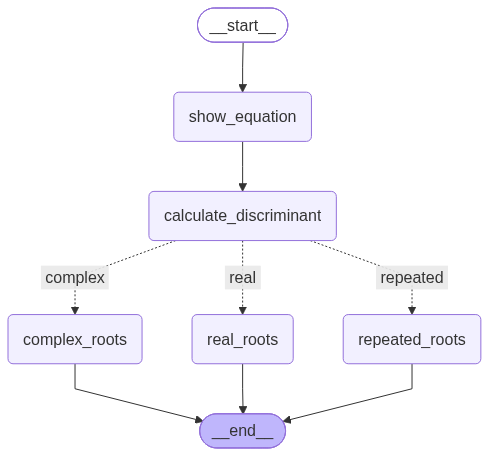

In [15]:
workflow

In [16]:
initial_state = {
    "a": 1,
    "b": -3,
    "c": 2
}

workflow.invoke(initial_state)

{'a': 1,
 'b': -3,
 'c': 2,
 'equation': '1x^2 + -3x + 2 = 0',
 'discriminant': 1,
 'result': 'The roots are real and distinct: 2.0 and 1.0'}